In [1]:
#used to allow importing of physicsnemo
import sys
sys.path.append("/global/u2/k/kfrields/climsim-kaggle-edition")
from physicsnemo.models.diffusion import *
from baseline_models.unet.training_default.climsim_datasets import *
import numpy as np
from sklearn.metrics import r2_score
import torch
import os, gc
from climsim_utils.data_utils import *
from tqdm import tqdm
from matplotlib import cm
import torch
import statsmodels.api as sm # For QQ plot
from baseline_models.unet.training_default.joint_model import JointModel
from omegaconf import OmegaConf
from torch.utils.data import Dataset, DataLoader
from modulus.distributed import DistributedManager
from torch.utils.data.distributed import DistributedSampler


In [2]:
base_path = '/pscratch/sd/k/kfrields/hugging/E3SM-MMF_saved_models/diffusion_models/rerun_standard_model_pruned_fixed_test/'
config_path = '/pscratch/sd/k/kfrields/hugging/E3SM-MMF_saved_models/diffusion_models/rerun_standard_model_pruned_fixed_test/saved_config.yaml'
with open(config_path, "r") as f:
    cfg=OmegaConf.load(f)
base_path = os.path.join(cfg.save_path, cfg.expname)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

res_std = torch.load(cfg.res_std_path)
res_std = res_std.to(torch.float32)

res_mean = torch.load(cfg.res_mean_path)
res_mean = res_mean.to(torch.float32)

preds_std = torch.load(cfg.preds_std_path)
preds_std = preds_std.to(torch.float32)

preds_mean = torch.load(cfg.preds_mean_path)
preds_mean = preds_mean.to(torch.float32)


grid_info = xr.open_dataset(cfg.grid_info_path)
input_mean = xr.open_dataset(cfg.input_mean_path)
input_max = xr.open_dataset(cfg.input_max_path)
input_min = xr.open_dataset(cfg.input_min_path)
output_scale = xr.open_dataset(cfg.output_scale_path)
qn_lbd = np.loadtxt(cfg.qn_lbd_path, delimiter=',')

data = data_utils(grid_info = grid_info, 
                  input_mean = input_mean, 
                  input_max = input_max, 
                  input_min = input_min, 
                  output_scale = output_scale)

# set variables to subset
if cfg.variable_subsets == 'v1':
    data.set_to_v1_vars()
elif cfg.variable_subsets == 'v1_dyn':
    data.set_to_v1_dyn_vars()
elif cfg.variable_subsets == 'v2':
    data.set_to_v2_vars()
elif cfg.variable_subsets == 'v2_dyn':
    data.set_to_v2_dyn_vars()
elif cfg.variable_subsets == 'v2_rh':
    data.set_to_v2_rh_vars()
elif cfg.variable_subsets == 'v2_rh_mc':
    data.set_to_v2_rh_mc_vars()
elif cfg.variable_subsets == 'v3':
    data.set_to_v3_vars()
elif cfg.variable_subsets == 'v4':
    data.set_to_v4_vars()
else:
    raise ValueError('Unknown variable subset')

input_size = data.input_feature_len
output_size = data.target_feature_len

input_sub, input_div, out_scale = data.save_norm(write=False)



train_dataset = TrainingDataset(parent_path = cfg.data_path,
                                input_sub = input_sub,
                                input_div = input_div,
                                out_scale = out_scale,
                                qinput_prune = cfg.qinput_prune,
                                output_prune = cfg.output_prune,
                                strato_lev = cfg.strato_lev,
                                qn_lbd = qn_lbd,
                                decouple_cloud = cfg.decouple_cloud,
                                aggressive_pruning = cfg.aggressive_pruning,
                                strato_lev_qc = cfg.strato_lev_qc,
                                strato_lev_qinput = cfg.strato_lev_qinput,
                                strato_lev_tinput = cfg.strato_lev_tinput,
                                strato_lev_out = cfg.strato_lev_out,
                                input_clip = cfg.input_clip,
                                input_clip_rhonly = cfg.input_clip_rhonly)


train_loader = DataLoader(train_dataset, 
                                batch_size=cfg.batch_size, 
                                shuffle= True,
                                sampler=None,
                                drop_last=True,
                                #persistent_workers=True,# TEMPORARILY ADDED FOR DEBUGGING
                                #pin_memory=torch.cuda.is_available(),# TEMPORARILY DISABLED FOR DEBUGGING
                                num_workers=cfg.num_workers)

deterministic_model_path = os.path.join(base_path, 'unet_model.pt')
deterministic_model = torch.jit.load(deterministic_model_path).to(device)
deterministic_model.eval()

#Load residual model
diff_path = os.path.join(base_path, 'diff_model.pt')
diff_model = torch.load(diff_path).to(device)
diff_model.eval()
print('here')


joint_model = JointModel(deterministic_model,diff_model, res_std, res_mean, 
                            preds_std, preds_mean, 
                            input_profile_num = data.input_profile_num, 
                            input_scalar_num = data.input_scalar_num,
                            target_profile_num = data.target_profile_num,
                            target_scalar_num = data.target_scalar_num, 
                            condition_channel_num = data.target_profile_num  + data.target_scalar_num + data.input_profile_num + data.input_scalar_num,
                            p_mean = cfg.diffusion_model.p_mean,
                            p_std = cfg.diffusion_model.p_std).to(device)
joint_model.eval()

input paths: ['/pscratch/sd/j/jerrylin/hugging/E3SM-MMF_ne4/preprocessing/v2_rh_mc/train_set/12/train_input.h5', '/pscratch/sd/j/jerrylin/hugging/E3SM-MMF_ne4/preprocessing/v2_rh_mc/train_set/72/train_input.h5', '/pscratch/sd/j/jerrylin/hugging/E3SM-MMF_ne4/preprocessing/v2_rh_mc/train_set/22/train_input.h5', '/pscratch/sd/j/jerrylin/hugging/E3SM-MMF_ne4/preprocessing/v2_rh_mc/train_set/32/train_input.h5', '/pscratch/sd/j/jerrylin/hugging/E3SM-MMF_ne4/preprocessing/v2_rh_mc/train_set/71/train_input.h5', '/pscratch/sd/j/jerrylin/hugging/E3SM-MMF_ne4/preprocessing/v2_rh_mc/train_set/52/train_input.h5', '/pscratch/sd/j/jerrylin/hugging/E3SM-MMF_ne4/preprocessing/v2_rh_mc/train_set/21/train_input.h5', '/pscratch/sd/j/jerrylin/hugging/E3SM-MMF_ne4/preprocessing/v2_rh_mc/train_set/51/train_input.h5', '/pscratch/sd/j/jerrylin/hugging/E3SM-MMF_ne4/preprocessing/v2_rh_mc/train_set/62/train_input.h5', '/pscratch/sd/j/jerrylin/hugging/E3SM-MMF_ne4/preprocessing/v2_rh_mc/train_set/61/train_input.h

JointModel(
  (deterministic_model): RecursiveScriptModule(
    original_name=Unet
    (enc): RecursiveScriptModule(
      original_name=ModuleDict
      (64_conv): RecursiveScriptModule(original_name=Conv1d)
      (64_block0): RecursiveScriptModule(
        original_name=UNetBlock_noatten
        (norm0): RecursiveScriptModule(original_name=GroupNorm)
        (conv0): RecursiveScriptModule(original_name=Conv1d)
        (norm1): RecursiveScriptModule(original_name=GroupNorm)
        (conv1): RecursiveScriptModule(original_name=Conv1d)
      )
      (64_block1): RecursiveScriptModule(
        original_name=UNetBlock_noatten
        (norm0): RecursiveScriptModule(original_name=GroupNorm)
        (conv0): RecursiveScriptModule(original_name=Conv1d)
        (norm1): RecursiveScriptModule(original_name=GroupNorm)
        (conv1): RecursiveScriptModule(original_name=Conv1d)
      )
      (32_down): RecursiveScriptModule(
        original_name=UNetBlock_noatten
        (norm0): RecursiveScrip

In [3]:
train_loop = tqdm(train_loader)

  0%|          | 0/137961 [00:00<?, ?it/s]

In [62]:
with torch.no_grad():
    max_steps = 500
    normalized_res_list = []
    
    joint_model.deterministic_model.eval()
    joint_model.res_model.eval()
    
    current_step = 0
    for data_input, target in train_loop:
        if current_step >= 5:
            break
        data_input, target = data_input.to(device), target.to(device)
    
        #(B, C*L) --> (B, C, L)
        reshape_input = joint_model.reshape_input(data_input)
        target = joint_model.reshape_target(target)
        
        #=====Calculate Residual=====
        #output shape is (B, C, L), scalar values are all expanded mean value across levels
        output = joint_model.deterministic_model(reshape_input)
        
        residual = target - output
        residual = residual.to(output.device)
        
        #======Normalize input and condition data======
        #normalized_residual = residual
        safe_std = torch.clamp(joint_model.res_std, min=1e-2).to(device)
        normalized_residual = ((residual)/((safe_std+ 1e-8)))*.5
        reshaped_normalized_residual = joint_model.reverse_reshape_target(normalized_residual)
        #print(torch.cuda.memory_summary())
        current_step += 1
        normalized_res_list.append(reshaped_normalized_residual.cpu().numpy())
    
    true_res_stack = np.stack(normalized_res_list, axis = 0)

/global/u2/k/kfrields/climsim-kaggle-edition/baseline_models/unet/training_default/climsim_datasets.py:132: RuntimeWarning: divide by zero encountered in divide
  x = (x - self.input_sub) / self.input_div
/global/u2/k/kfrields/climsim-kaggle-edition/baseline_models/unet/training_default/climsim_datasets.py:132: RuntimeWarning: divide by zero encountered in divide
  x = (x - self.input_sub) / self.input_div
/global/u2/k/kfrields/climsim-kaggle-edition/baseline_models/unet/training_default/climsim_datasets.py:132: RuntimeWarning: divide by zero encountered in divide
  x = (x - self.input_sub) / self.input_div
/global/u2/k/kfrields/climsim-kaggle-edition/baseline_models/unet/training_default/climsim_datasets.py:132: RuntimeWarning: divide by zero encountered in divide
  x = (x - self.input_sub) / self.input_div
/global/u2/k/kfrields/climsim-kaggle-edition/baseline_models/unet/training_default/climsim_datasets.py:132: RuntimeWarning: divide by zero encountered in divide
  x = (x - self.inp

In [21]:
normalized_res_stack.reshape(-1, 308).shape

(2560, 308)

In [63]:
true_res_stack_reshaped = true_res_stack.reshape(-1, 308)

true_sample_wise_std = true_res_stack_reshaped.std(axis = 0)
print(true_sample_wise_std.shape)
print(np.median(true_sample_wise_std))


#(B,C*L)->(B,C,L)
true_res_stack = joint_model.reshape_target(torch.tensor(true_res_stack_reshaped))

(308,)
0.550958


In [78]:
torch.tensor(1).shape

torch.Size([])

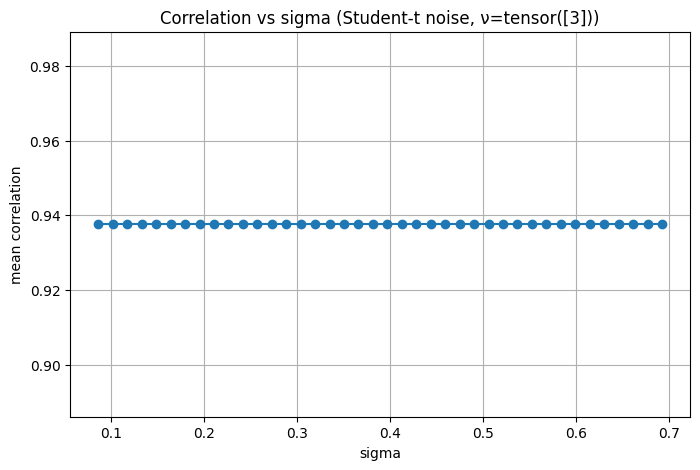

In [85]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# true_res_stack: (B, C, L)
x0 = true_res_stack  # normalized residuals

# Choose degrees of freedom for Student-t (ν)
nu = 3   # try 3, 5, 7 like the paper

# Range of sigma values to test
sigma_values = torch.linspace(.05, .4, steps=40)

corr_means = []

reweighted_sigma_values = []

for sigma in sigma_values:
    sigma = torch.tensor([sigma])
    nu = torch.tensor([nu])
    B,C,L = x0.shape
    
    # Gaussian base noise
    z = torch.randn_like(x0)

    # One kappa per sample
    kappa = torch.distributions.Chi2(df=nu).sample((B,))
    kappa = (kappa / nu).view(B, 1, 1)

    # Student‑t noise
    t_noise = z / torch.sqrt(kappa)

    # Normalize to unit variance (REQUIRED for EDM)
    #t_noise = t_noise * math.sqrt((self.nu - 2) / self.nu)

    # Apply sigma
    #print(sigma)
    #print(sigma.shape)
    reshaped_sigma = sigma.repeat(B, 1, 1)
    n = t_noise * sigma
    #print(f'n shape is {n.shape}')
    #print(f'normalized_residual shape is {normalized_residual.shape}')
    noised_residual = x0 + n


    reweighted_sigma = sigma*torch.sqrt(nu/(nu-2))
    reweighted_sigma_values.append(reweighted_sigma)
    
    # Flatten per-sample
    x0_flat = x0.view(x0.size(0), -1)
    xs_flat = x_sigma.view(x_sigma.size(0), -1)

    # Compute correlation per sample
    corrs = []
    for i in range(x0_flat.size(0)):
        c = np.corrcoef(
            x0_flat[i].cpu().numpy(),
            xs_flat[i].cpu().numpy()
        )[0, 1]
        corrs.append(c)
    #print(x0_flat)
    #print(xs_flat)
    corr_means.append(np.mean(corrs))

# Convert to numpy for plotting
reweighted_sigma_values_tensor = torch.tensor(reweighted_sigma_values)
sigma_values_np = reweighted_sigma_values_tensor.cpu().numpy()
corr_means_np = np.array(corr_means)

# Plot
plt.figure(figsize=(8,5))
plt.plot(sigma_values_np, corr_means_np, marker='o')
plt.xlabel("sigma")
plt.ylabel("mean correlation")
plt.title(f"Correlation vs sigma (Student-t noise, ν={nu})")
plt.grid(True)
plt.show()


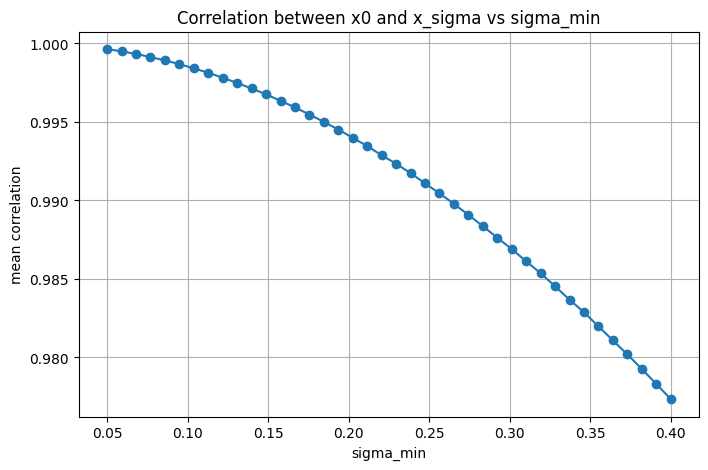

In [35]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# true_res_stack: (B, C, L)
# normalized_res_stack: (B, C, L)
# Make sure these are already on CPU or move them

x0 = true_res_stack  # your normalized true residuals

# Range of sigma_max values to test
sigma_values = torch.linspace(0.05, .4, steps=40)  # adjust upper bound as needed

corr_means = []

for sigma_min in sigma_values:
    # Add noise with fixed sigma_max
    n = torch.randn_like(x0) * sigma_min
    x_sigma = x0 + n

    # Flatten per-sample
    x0_flat = x0.view(x0.size(0), -1)
    xs_flat = x_sigma.view(x_sigma.size(0), -1)

    # Compute correlation per sample
    corrs = []
    for i in range(x0_flat.size(0)):
        c = np.corrcoef(
            x0_flat[i].cpu().numpy(),
            xs_flat[i].cpu().numpy()
        )[0, 1]
        corrs.append(c)

    corr_means.append(np.mean(corrs))

# Convert to numpy for plotting
sigma_values_np = sigma_values.cpu().numpy()
corr_means_np = np.array(corr_means)

# Plot
plt.figure(figsize=(8,5))
plt.plot(sigma_values_np, corr_means_np, marker='o')
plt.xlabel("sigma_min")
plt.ylabel("mean correlation")
plt.title("Correlation between x0 and x_sigma vs sigma_min")
plt.grid(True)
plt.show()


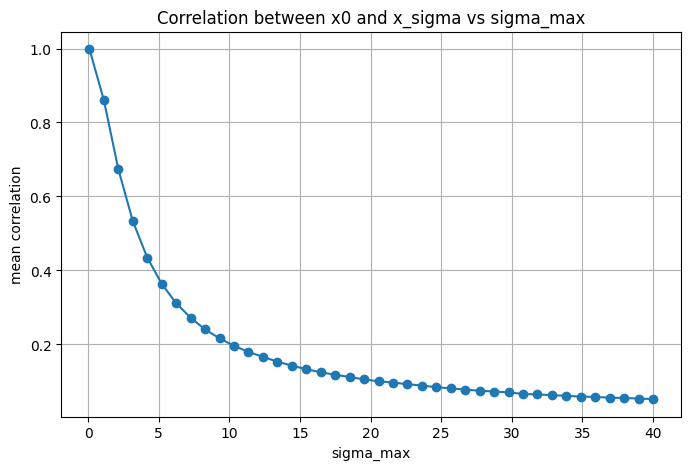

In [31]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# true_res_stack: (B, C, L)
# normalized_res_stack: (B, C, L)
# Make sure these are already on CPU or move them

x0 = true_res_stack  # your normalized true residuals

# Range of sigma_max values to test
sigma_values = torch.linspace(0.1, 40, steps=40)  # adjust upper bound as needed

corr_means = []

for sigma_max in sigma_values:
    # Add noise with fixed sigma_max
    n = torch.randn_like(x0) * sigma_max
    x_sigma = x0 + n

    # Flatten per-sample
    x0_flat = x0.view(x0.size(0), -1)
    xs_flat = x_sigma.view(x_sigma.size(0), -1)

    # Compute correlation per sample
    corrs = []
    for i in range(x0_flat.size(0)):
        c = np.corrcoef(
            x0_flat[i].cpu().numpy(),
            xs_flat[i].cpu().numpy()
        )[0, 1]
        corrs.append(c)

    corr_means.append(np.mean(corrs))

# Convert to numpy for plotting
sigma_values_np = sigma_values.cpu().numpy()
corr_means_np = np.array(corr_means)

# Plot
plt.figure(figsize=(8,5))
plt.plot(sigma_values_np, corr_means_np, marker='o')
plt.xlabel("sigma_max")
plt.ylabel("mean correlation")
plt.title("Correlation between x0 and x_sigma vs sigma_max")
plt.grid(True)
plt.show()


/tmp/ipykernel_1116938/1530534422.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  scale = torch.tensor(sigma)


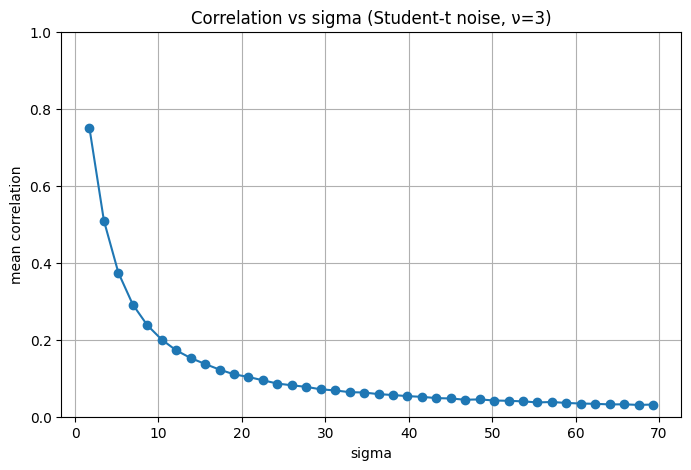

In [59]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# true_res_stack: (B, C, L)
x0 = true_res_stack  # normalized residuals

# Choose degrees of freedom for Student-t (ν)
nu = 3   # try 3, 5, 7 like the paper

# Range of sigma values to test
sigma_values = torch.linspace(1, 40, steps=40)

corr_means = []

reweighted_sigma_values = []

for sigma in sigma_values:
    B,C,L = x0.shape
    degrees_of_freedom = torch.tensor([3.0])
    mean = torch.tensor([0.0])
    scale = torch.tensor(sigma)

    t_distribution = StudentT(df=degrees_of_freedom, loc=mean, scale=scale)
    n = t_distribution.sample(sample_shape = torch.Size([B,C,L])).squeeze(-1)
    
    x_sigma = x0 + n

    reweighted_sigma = sigma*torch.sqrt(degrees_of_freedom/(degrees_of_freedom-2))
    reweighted_sigma_values.append(reweighted_sigma)
    
    # Flatten per-sample
    x0_flat = x0.view(x0.size(0), -1)
    xs_flat = x_sigma.view(x_sigma.size(0), -1)

    # Compute correlation per sample
    corrs = []
    for i in range(x0_flat.size(0)):
        c = np.corrcoef(
            x0_flat[i].cpu().numpy(),
            xs_flat[i].cpu().numpy()
        )[0, 1]
        corrs.append(c)
    #print(x0_flat)
    #print(xs_flat)
    corr_means.append(np.mean(corrs))

# Convert to numpy for plotting
reweighted_sigma_values_tensor = torch.tensor(reweighted_sigma_values)
sigma_values_np = reweighted_sigma_values_tensor.cpu().numpy()
corr_means_np = np.array(corr_means)

# Plot
plt.figure(figsize=(8,5))
plt.plot(sigma_values_np, corr_means_np, marker='o')
plt.xlabel("sigma")
plt.ylabel("mean correlation")
plt.title(f"Correlation vs sigma (Student-t noise, ν={nu})")
plt.grid(True)
plt.ylim(0, 1) #
plt.show()


In [40]:
sigma_max = 40
sigma_min = 1.5
rho = 7
num_steps = 18

step_indices = torch.arange(num_steps)
t_steps = (sigma_max ** (1 / rho) + step_indices / (num_steps - 1) * (sigma_min ** (1 / rho) - sigma_max ** (1 / rho))) ** rho

In [42]:
t_steps[0]

tensor(40.0000)

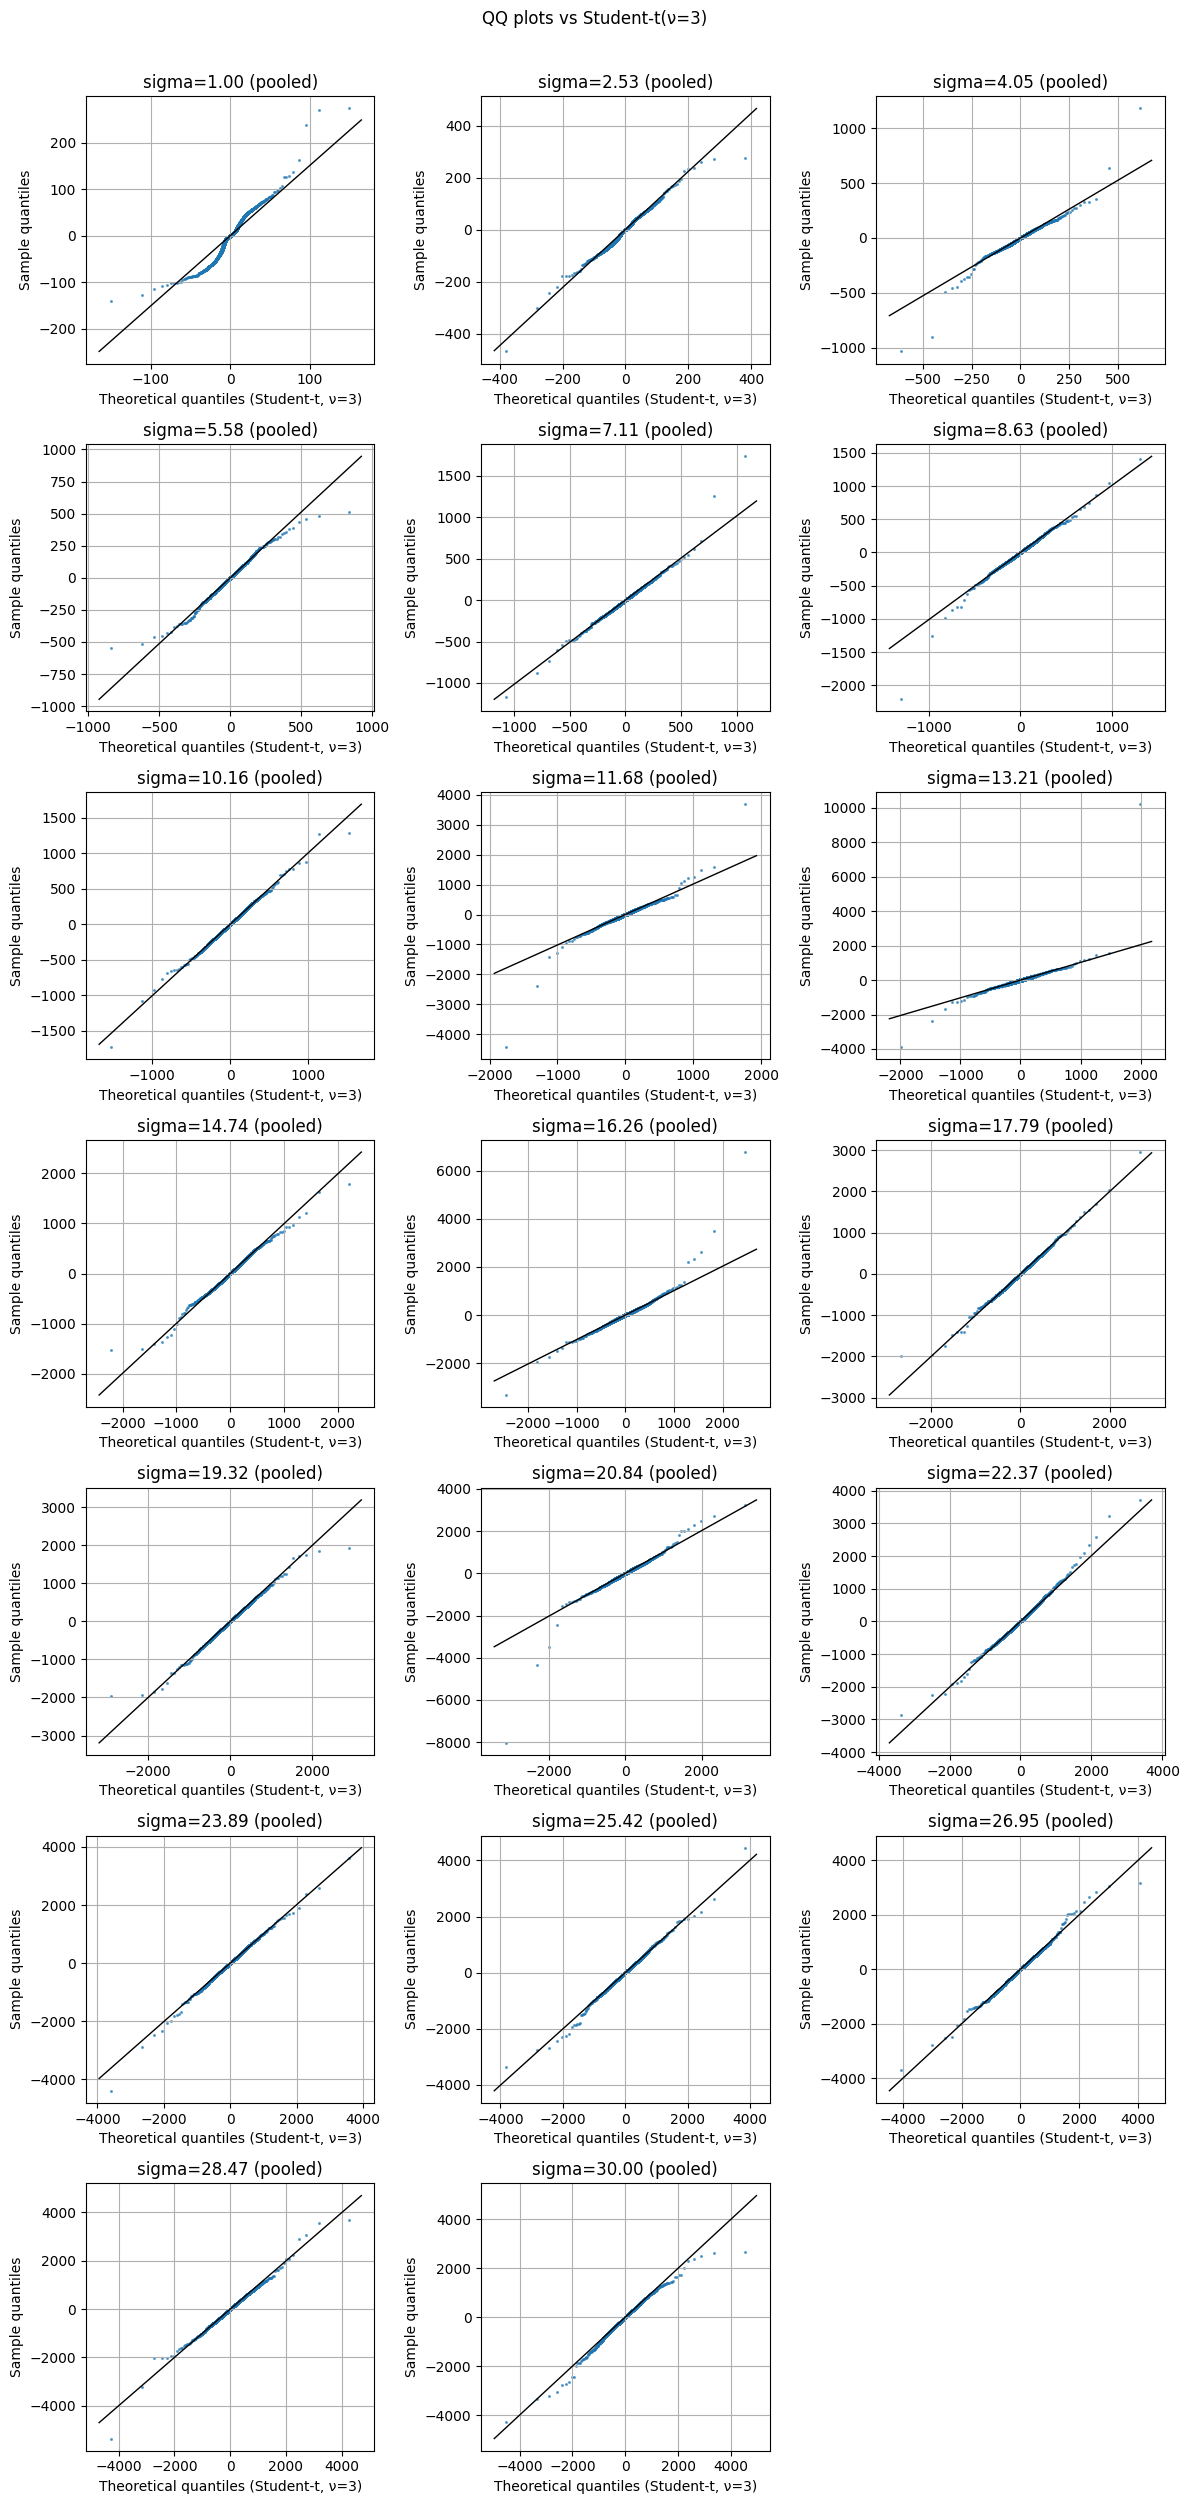

KS test (pooled) per sigma:
 sigma=1.000  KS-stat=0.0190  p=0.0000e+00
 sigma=2.526  KS-stat=0.1878  p=0.0000e+00
 sigma=4.053  KS-stat=0.2615  p=0.0000e+00
 sigma=5.579  KS-stat=0.3044  p=0.0000e+00
 sigma=7.105  KS-stat=0.3326  p=0.0000e+00
 sigma=8.632  KS-stat=0.3527  p=0.0000e+00
 sigma=10.158  KS-stat=0.3678  p=0.0000e+00
 sigma=11.684  KS-stat=0.3801  p=0.0000e+00
 sigma=13.211  KS-stat=0.3895  p=0.0000e+00
 sigma=14.737  KS-stat=0.3978  p=0.0000e+00
 sigma=16.263  KS-stat=0.4043  p=0.0000e+00
 sigma=17.789  KS-stat=0.4102  p=0.0000e+00
 sigma=19.316  KS-stat=0.4149  p=0.0000e+00
 sigma=20.842  KS-stat=0.4196  p=0.0000e+00
 sigma=22.368  KS-stat=0.4232  p=0.0000e+00
 sigma=23.895  KS-stat=0.4269  p=0.0000e+00
 sigma=25.421  KS-stat=0.4305  p=0.0000e+00
 sigma=26.947  KS-stat=0.4333  p=0.0000e+00
 sigma=28.474  KS-stat=0.4359  p=0.0000e+00
 sigma=30.000  KS-stat=0.4377  p=0.0000e+00


'\n# -------------------------\n# Optional: single pooled QQ for a chosen sigma\n# -------------------------\nchosen_sigma = float(sigma_values[len(sigma_values)//2].item())\nz = torch.randn_like(x0)\nkappa = torch.distributions.Chi2(df=nu).sample(x0.shape).to(x0.device)\nt_noise = z / torch.sqrt(kappa / nu)\nn = t_noise * chosen_sigma\nx_sigma = x0 + n\npooled = x_sigma.view(-1).numpy()\n\nplt.figure(figsize=(6,6))\nqq_plot_against_student_t(pooled, plt.gca(), nu,\n                          title=f"Pooled QQ (sigma={chosen_sigma:.2f})")\nplt.show()\n'

In [65]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# -------------------------
# Inputs
# -------------------------
x0 = true_res_stack.cpu()  # ensure on CPU

# Degrees of freedom for Student-t
nu = 3   # try 3, 5, 7 like the paper

# sigma values to test
sigma_values = torch.linspace(1, 30, steps=20)

POOL = True
RUN_KS = True

# -------------------------
# Helper: QQ plotting against Student-t(ν)
# -------------------------
def qq_plot_against_student_t(data, ax, nu, sigma, title=None, marker='.', color='C0'):
    """
    QQ plot comparing data to Student-t(ν).
    """
    data = np.asarray(data, dtype=np.float64)

    # Use scipy.probplot with Student-t distribution
    (theoretical, ordered), (slope, intercept, r) = stats.probplot(
        data, dist=stats.t(df=nu, scale = sigma)
    )

    ax.scatter(theoretical, ordered, s=6, alpha=0.6, color=color, marker=marker)

    # reference line
    xlims = ax.get_xlim()
    xl = np.linspace(xlims[0], xlims[1], 100)
    ax.plot(xl, slope * xl + intercept, color='k', linewidth=1)

    ax.set_xlabel(f"Theoretical quantiles (Student-t, ν={nu})")
    ax.set_ylabel("Sample quantiles")
    if title:
        ax.set_title(title)
    ax.grid(True)

# -------------------------
# Main loop
# -------------------------
n_sigma = len(sigma_values)
ncols = 3
nrows = int(np.ceil(n_sigma / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.5 * nrows))
axes = np.array(axes).reshape(-1)

ks_results = []

for idx, sigma_max in enumerate(sigma_values):
    sigma = float(sigma_max.item())

    B,C,L = x0.shape
    degrees_of_freedom = torch.tensor(float(nu))
    mean = torch.tensor([0.0])
    scale = torch.tensor(sigma)

    t_distribution = StudentT(df=degrees_of_freedom, loc=mean, scale=scale)
    n = t_distribution.sample(sample_shape = torch.Size([B,C,L])).squeeze(-1)
    
    x_sigma = x0 + n
    ax = axes[idx]

    if POOL:
        pooled = x_sigma.view(-1).numpy()
        qq_plot_against_student_t(pooled, ax, nu, sigma = sigma, title=f"sigma={sigma:.2f} (pooled)")

        if RUN_KS:
            ks_stat, ks_p = stats.kstest(pooled, 't', args=(nu,))
            ks_results.append((sigma, ks_stat, ks_p))

    else:
        B = x_sigma.size(0)
        n_to_plot = min(4, B)
        colors = ['C0', 'C1', 'C2', 'C3']

        for i in range(n_to_plot):
            sample = x_sigma[i].view(-1).numpy()
            qq_plot_against_student_t(sample, ax, nu,
                                      title=f"sigma={sigma:.2f}",
                                      marker='.', color=colors[i])

            if RUN_KS:
                ks_stat, ks_p = stats.kstest(sample, 't', args=(nu,))
                ks_results.append((sigma, i, ks_stat, ks_p))

        if n_to_plot > 1:
            ax.legend([f"sample {i}" for i in range(n_to_plot)],
                      loc='best', fontsize='small')

# hide unused axes
for j in range(n_sigma, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.suptitle(f"QQ plots vs Student-t(ν={nu})", y=1.02)
plt.show()

# -------------------------
# Summarize KS results
# -------------------------
if RUN_KS:
    if POOL:
        print("KS test (pooled) per sigma:")
        for sigma, ks_stat, ks_p in ks_results:
            print(f" sigma={sigma:.3f}  KS-stat={ks_stat:.4f}  p={ks_p:.4e}")
    else:
        print("KS test (per-sample entries): (sigma, sample_idx, KS-stat, p)")
        for entry in ks_results:
            print(entry)
'''
# -------------------------
# Optional: single pooled QQ for a chosen sigma
# -------------------------
chosen_sigma = float(sigma_values[len(sigma_values)//2].item())
z = torch.randn_like(x0)
kappa = torch.distributions.Chi2(df=nu).sample(x0.shape).to(x0.device)
t_noise = z / torch.sqrt(kappa / nu)
n = t_noise * chosen_sigma
x_sigma = x0 + n
pooled = x_sigma.view(-1).numpy()

plt.figure(figsize=(6,6))
qq_plot_against_student_t(pooled, plt.gca(), nu,
                          title=f"Pooled QQ (sigma={chosen_sigma:.2f})")
plt.show()
'''

In [1]:
signal_var = x0_flat.var(dim=1).mean()
noise_var  = (sigma**2).mean()  # if eps ~ N(0,1)
snr = signal_var / noise_var
print(snr)

NameError: name 'x0_flat' is not defined

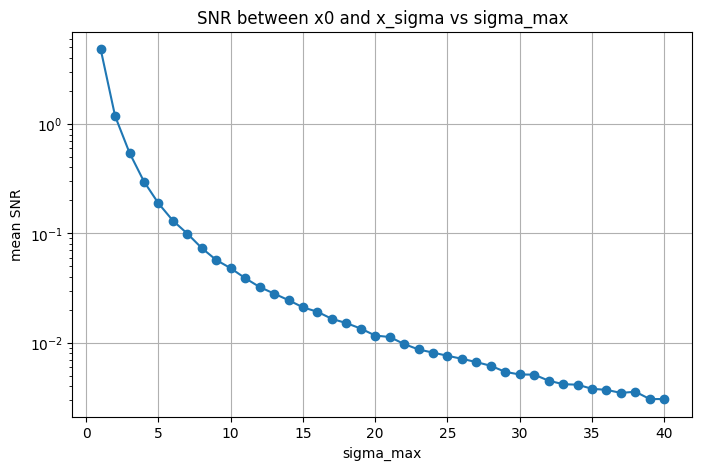

In [87]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# x0 = normalized true residuals (B, C, L)
x0 = true_res_stack

# Range of sigma_max values to test
sigma_values = torch.linspace(1, 40, steps=40)  # adjust upper bound as needed

snr_means = []
nu = 3
for sigma_max in sigma_values:
    sigma = torch.tensor([sigma_max])
    nu = torch.tensor([nu])
    B,C,L = x0.shape
    
    # Gaussian base noise
    z = torch.randn_like(x0)

    # One kappa per sample
    kappa = torch.distributions.Chi2(df=nu).sample((B,))
    kappa = (kappa / nu).view(B, 1, 1)

    # Student‑t noise
    t_noise = z / torch.sqrt(kappa)

    # Normalize to unit variance (REQUIRED for EDM)
    #t_noise = t_noise * math.sqrt((self.nu - 2) / self.nu)

    # Apply sigma
    #print(sigma)
    #print(sigma.shape)
    reshaped_sigma = sigma.repeat(B, 1, 1)
    n = t_noise * sigma
    #print(f'n shape is {n.shape}')
    #print(f'normalized_residual shape is {normalized_residual.shape}')
    x_sigma = x0 + n


    reweighted_sigma = sigma*torch.sqrt(nu/(nu-2))
    reweighted_sigma_values.append(reweighted_sigma)
    
    # Flatten per-sample
    x0_flat = x0.view(x0.size(0), -1)
    xs_flat = x_sigma.view(x_sigma.size(0), -1)

    # Compute SNR per sample
    snrs = []
    for i in range(x0_flat.size(0)):
        sig_var = x0_flat[i].var().item()
        noise_var = (xs_flat[i] - x0_flat[i]).var().item()
        snrs.append(sig_var / noise_var)

    snr_means.append(np.mean(snrs))

# Convert to numpy for plotting
sigma_values_np = sigma_values.cpu().numpy()
snr_means_np = np.array(snr_means)

# Plot
plt.figure(figsize=(8,5))
plt.plot(sigma_values_np, snr_means_np, marker='o')
plt.xlabel("sigma_max")
plt.ylabel("mean SNR")
plt.title("SNR between x0 and x_sigma vs sigma_max")
plt.yscale("log")  # SNR spans orders of magnitude
plt.grid(True)
plt.show()


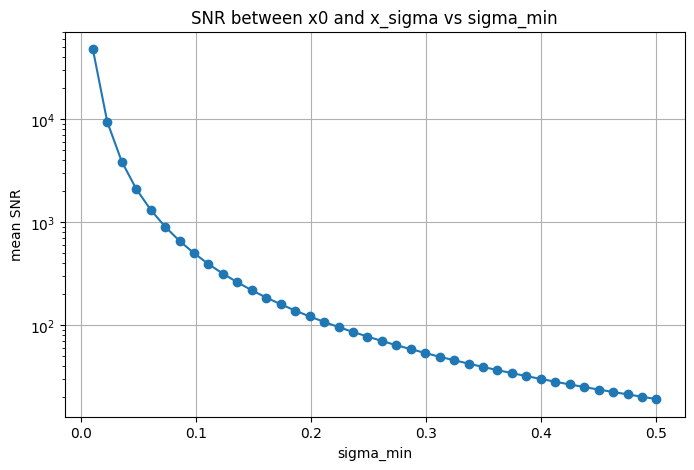

In [18]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# x0 = normalized true residuals (B, C, L)
x0 = true_res_stack

# Range of sigma_max values to test
sigma_values = torch.linspace(.01, .5, steps=40)  # adjust upper bound as needed

snr_means = []

for sigma_min in sigma_values:
    # Add noise with fixed sigma_max
    n = torch.randn_like(x0) * sigma_min
    x_sigma = x0 + n

    # Flatten per-sample
    x0_flat = x0.view(x0.size(0), -1)
    xs_flat = x_sigma.view(x_sigma.size(0), -1)

    # Compute SNR per sample
    snrs = []
    for i in range(x0_flat.size(0)):
        sig_var = x0_flat[i].var().item()
        noise_var = (xs_flat[i] - x0_flat[i]).var().item()
        snrs.append(sig_var / noise_var)

    snr_means.append(np.mean(snrs))

# Convert to numpy for plotting
sigma_values_np = sigma_values.cpu().numpy()
snr_means_np = np.array(snr_means)

# Plot
plt.figure(figsize=(8,5))
plt.plot(sigma_values_np, snr_means_np, marker='o')
plt.xlabel("sigma_min")
plt.ylabel("mean SNR")
plt.title("SNR between x0 and x_sigma vs sigma_min")
plt.yscale("log")  # SNR spans orders of magnitude
plt.grid(True)
plt.show()


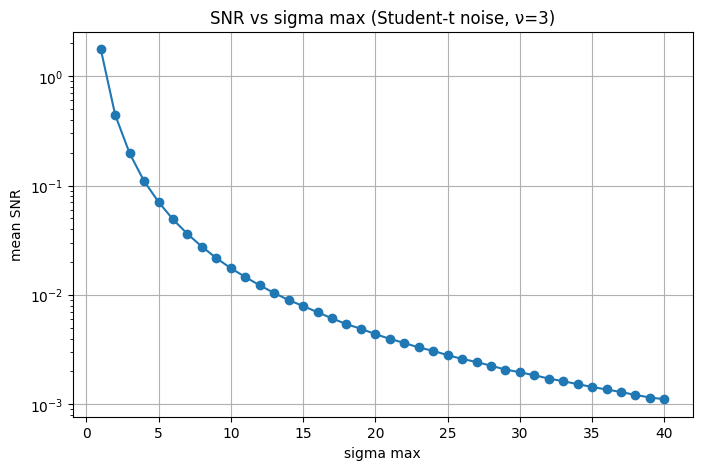

In [14]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# x0 = normalized true residuals (B, C, L)
x0 = true_res_stack

# Degrees of freedom for Student‑t noise
nu = 3   # try 3, 5, 7 like the paper

# Range of sigma values to test
sigma_values = torch.linspace(1, 40, steps=40)

snr_means = []

for sigma in sigma_values:

    # --- Student‑t noise (Pandey et al. 2024) ---
    z = torch.randn_like(x0)                     # Gaussian
    kappa = torch.distributions.Chi2(df=nu).sample(x0.shape).to(x0.device)
    t_noise = z / torch.sqrt(kappa / nu)         # Student‑t(ν)
    n = t_noise * sigma                          # scale by sigma
    # --------------------------------------------

    x_sigma = x0 + n

    # Flatten per-sample
    x0_flat = x0.view(x0.size(0), -1)
    xs_flat = x_sigma.view(x_sigma.size(0), -1)

    # Compute SNR per sample
    snrs = []
    for i in range(x0_flat.size(0)):
        sig_var = x0_flat[i].var().item()
        noise_var = (xs_flat[i] - x0_flat[i]).var().item()
        snrs.append(sig_var / noise_var)

    snr_means.append(np.mean(snrs))

# Convert to numpy for plotting
sigma_values_np = sigma_values.cpu().numpy()
snr_means_np = np.array(snr_means)

# Plot
plt.figure(figsize=(8,5))
plt.plot(sigma_values_np, snr_means_np, marker='o')
plt.xlabel("sigma max")
plt.ylabel("mean SNR")
plt.title(f"SNR vs sigma max (Student‑t noise, ν={nu})")
plt.yscale("log")
plt.grid(True)
plt.show()


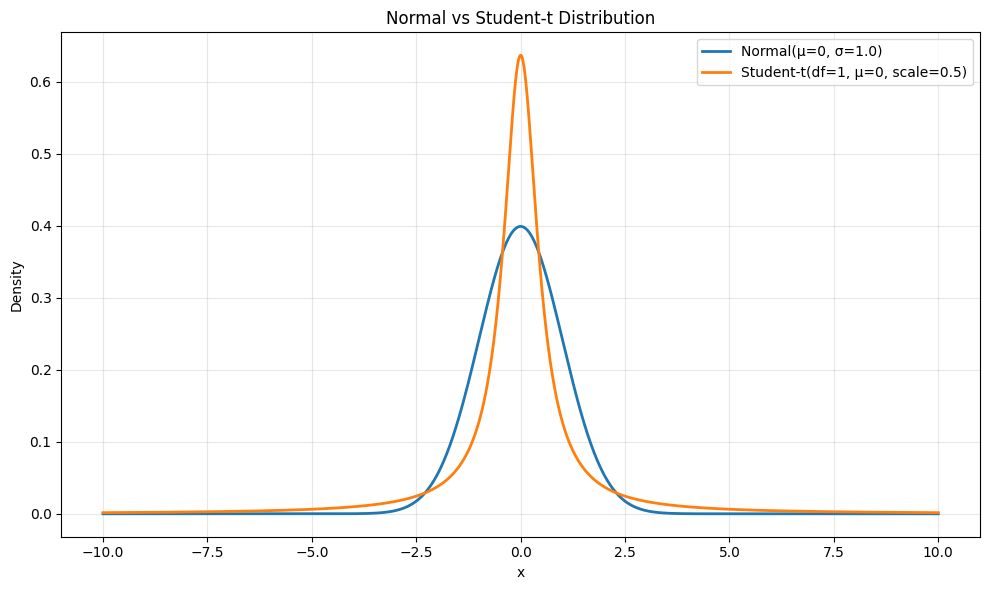

Points: [-5 -2  0  2  5]
Normal CDF: [2.86651572e-07 2.27501319e-02 5.00000000e-01 9.77249868e-01
 9.99999713e-01]
Student‑t CDF: [0.03172552 0.07797913 0.5        0.92202087 0.96827448]


In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, t

# -----------------------------
# Parameters
# -----------------------------
mu_normal = 0
sigma_normal = 1.0

mu_t = 0
df_t = 1          # degrees of freedom (heavy-tailed)
scale_t = 0.5    # analogous to std for t-dist

# Range for plotting
x = np.linspace(-10, 10, 2000)

# -----------------------------
# Compute PDFs
# -----------------------------
normal_pdf = norm.pdf(x, loc=mu_normal, scale=sigma_normal)
t_pdf = t.pdf(x, df=df_t, loc=mu_t, scale=scale_t)

# -----------------------------
# Plot PDFs
# -----------------------------
plt.figure(figsize=(10, 6))
plt.plot(x, normal_pdf, label=f"Normal(μ={mu_normal}, σ={sigma_normal})", linewidth=2)
plt.plot(x, t_pdf, label=f"Student‑t(df={df_t}, μ={mu_t}, scale={scale_t})", linewidth=2)

plt.title("Normal vs Student‑t Distribution")
plt.xlabel("x")
plt.ylabel("Density")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# Compute CDFs at specific points
# -----------------------------
points = np.array([-5, -2, 0, 2, 5])   # choose any values you want

normal_cdf_vals = norm.cdf(points, loc=mu_normal, scale=sigma_normal)
t_cdf_vals = t.cdf(points, df=df_t, loc=mu_t, scale=scale_t)

print("Points:", points)
print("Normal CDF:", normal_cdf_vals)
print("Student‑t CDF:", t_cdf_vals)
